In [9]:
import threading
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract

class IBDataFetcher(EWrapper, EClient):
    def __init__(self):
        EClient.__init__(self, self)
        self.data  = []
        self.ready = threading.Event()  # TWS 握手完成
        self.done  = threading.Event()  # 数据接收完成

    def nextValidId(self, orderId):
        self.ready.set()  # 收到这个回调说明连接已就绪

    def historicalData(self, reqId, bar):
        self.data.append({
            'date':   bar.date,
            'open':   bar.open,
            'high':   bar.high,
            'low':    bar.low,
            'close':  bar.close,
            'volume': bar.volume,
        })

    def historicalDataEnd(self, reqId, start, end):
        self.done.set()

    def error(self, reqId, errorCode, errorString, advancedOrderRejectJson=''):
        if errorCode not in (2104, 2106, 2107, 2108, 2158):
            print(f'[ERROR] code={errorCode}: {errorString}')

def get_ibkr_data(symbol, duration='4 Y', bar_size='1 day', port=7497, client_id=1):
    """TWS 需在后台运行。port: 7497=模拟, 7496=真实"""
    app = IBDataFetcher()
    app.connect('127.0.0.1', port, clientId=client_id)

    contract = Contract()
    contract.symbol   = symbol
    contract.secType  = 'STK'
    contract.exchange = 'SMART'
    contract.currency = 'USD'

    threading.Thread(target=app.run, daemon=True).start()
    app.ready.wait(timeout=10)   # 等 nextValidId 回调，确认连接就绪

    app.reqHistoricalData(
        reqId=1, contract=contract, endDateTime='',
        durationStr=duration, barSizeSetting=bar_size,
        whatToShow='TRADES', useRTH=1, formatDate=1,
        keepUpToDate=False, chartOptions=[]
    )
    app.done.wait(timeout=60)
    app.disconnect()

    if not app.data:
        raise RuntimeError('没有收到数据，请确认 TWS 已开启且 API 已启用')

    df = pd.DataFrame(app.data)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    for col in ['open', 'high', 'low', 'close']:
        df[col] = df[col].astype(float)
    return df

In [21]:
symbol    = 'NVDA'
startDate = '2022-01-01'
endDate   = '2026-01-01'

df_raw = get_ibkr_data(symbol, duration='4 Y')
df_raw = df_raw[(df_raw['date'] >= startDate) & (df_raw['date'] <= endDate)].reset_index(drop=True)
print(f'{symbol}: {len(df_raw)} bars  {df_raw["date"].iloc[0].date()} -> {df_raw["date"].iloc[-1].date()}')

# 保存到 CSV，供其他 notebook 使用
df_raw.to_csv(f'data_{symbol}.csv', index=False)
print(f'data_{symbol}.csv 已保存')
df_raw.tail()

NVDA: 931 bars  2022-04-18 -> 2025-12-31
data_NVDA.csv 已保存


,date,open,high,low,close,volume
926,2025-12-24,187.94,188.91,186.59,188.61,461271
927,2025-12-26,189.92,192.69,188.00,190.53,1015218
928,2025-12-29,187.70,188.76,185.92,188.22,779741
929,2025-12-30,188.23,188.99,186.93,187.54,662000
930,2025-12-31,189.57,190.56,186.49,186.50,788216


In [12]:
BB_WINDOW = 20
BB_STD    = 2.0
HOLD_DAYS = 5
BUY1_PCT  = 0.10
BUY2_PCT  = 0.15
FEE_RATE  = 0.0001
INIT_CASH = 1000

def prepare_bb(df, window=BB_WINDOW, n_std=BB_STD):
    df = df.copy()
    df['bb_mid']   = df['close'].rolling(window).mean()
    df['bb_std']   = df['close'].rolling(window).std()
    df['bb_upper'] = df['bb_mid'] + n_std * df['bb_std']
    df['bb_lower'] = df['bb_mid'] - n_std * df['bb_std']
    return df

def run_backtest(df, init_cash=INIT_CASH, buy1_pct=BUY1_PCT, buy2_pct=BUY2_PCT,
                 hold_days=HOLD_DAYS, fee=FEE_RATE):
    cash, position, entry_bar, second_done = init_cash, 0.0, None, False
    equity_curve, trades = [], []
    df = df.dropna(subset=['bb_lower']).reset_index(drop=True)

    for i, row in df.iterrows():
        close, low, bb_lower, date = float(row['close']), float(row['low']), float(row['bb_lower']), row['date']

        # 卖出
        if entry_bar is not None and (i - entry_bar) >= hold_days and position > 0:
            proceeds = position * close
            cash += proceeds - proceeds * fee
            trades.append({'date': date, 'action': 'SELL', 'price': close,
                           'shares': round(position, 4), 'value': round(proceeds, 2), 'days_held': i - entry_bar})
            position, entry_bar, second_done = 0.0, None, False

        # 买入
        if low < bb_lower:
            if entry_bar is None and cash > 0:                          # 第一次
                spend = cash * buy1_pct
                cash -= spend * (1 + fee)
                position += spend / close
                entry_bar = i
                trades.append({'date': date, 'action': 'BUY_1 (10%)', 'price': close,
                               'shares': round(spend/close, 4), 'value': round(spend, 2), 'days_held': 0})
            elif entry_bar is not None and (i-entry_bar)==1 and not second_done and cash > 0:  # 第二次
                spend = cash * buy2_pct
                cash -= spend * (1 + fee)
                position += spend / close
                second_done = True
                trades.append({'date': date, 'action': 'BUY_2 (15%)', 'price': close,
                               'shares': round(spend/close, 4), 'value': round(spend, 2), 'days_held': 1})

        equity_curve.append({'date': date, 'equity': cash + position * close,
                              'close': close, 'bb_lower': bb_lower,
                              'bb_upper': float(row['bb_upper']), 'bb_mid': float(row['bb_mid'])})

    return pd.DataFrame(equity_curve), pd.DataFrame(trades)

df = prepare_bb(df_raw)
res, trades_df = run_backtest(df)
trades_df

,date,action,price,shares,value,days_held
0,2022-06-13,BUY_1 (10%),15.65,6.3898,100.00,0
1,2022-06-21,SELL,16.57,6.3898,105.88,5
2,2022-08-26,BUY_1 (10%),16.26,6.1861,100.59,0
3,2022-08-29,BUY_2 (15%),15.80,8.5943,135.79,1
4,2022-09-02,SELL,13.65,14.7803,201.75,5
...,...,...,...,...,...,...
57,2025-09-08,SELL,168.31,1.3938,234.59,5
58,2025-11-21,BUY_1 (10%),178.88,0.5679,101.59,0
59,2025-12-01,SELL,179.92,0.5679,102.18,5
60,2025-12-12,BUY_1 (10%),175.02,0.5808,101.65,0


In [18]:
# ── 每轮交易盈亏分析 ──────────────────────────────────
rounds = []
i = 0
while i < len(trades_df):
    row = trades_df.iloc[i]

    # 找到一轮的起点（BUY_1）
    if row['action'] != 'BUY_1 (10%)':
        i += 1
        continue

    buy1 = row
    buy2 = None
    sell = None

    # 看下一条是 BUY_2 还是直接 SELL
    if i + 1 < len(trades_df):
        next_row = trades_df.iloc[i + 1]
        if next_row['action'] == 'BUY_2 (15%)':
            buy2 = next_row
            if i + 2 < len(trades_df):
                sell = trades_df.iloc[i + 2]
            i += 3
        elif next_row['action'] == 'SELL':
            sell = next_row
            i += 2
        else:
            i += 1
            continue
    else:
        i += 1
        continue

    if sell is None or sell['action'] != 'SELL':
        continue

    # 计算加权平均买入价
    total_shares = buy1['shares'] + (buy2['shares'] if buy2 is not None else 0)
    total_cost   = buy1['value']  + (buy2['value']  if buy2 is not None else 0)
    avg_buy_price = total_cost / total_shares if total_shares > 0 else 0

    sell_price  = sell['price']
    sell_value  = sell['value']
    pnl         = sell_value - total_cost
    pnl_pct     = pnl / total_cost * 100 if total_cost > 0 else 0

    rounds.append({
        'buy_date':       buy1['date'].strftime('%Y-%m-%d') if hasattr(buy1['date'], 'strftime') else str(buy1['date'])[:10],
        'sell_date':      sell['date'].strftime('%Y-%m-%d') if hasattr(sell['date'], 'strftime') else str(sell['date'])[:10],
        'buy1_price':     buy1['price'],
        'buy2_price':     buy2['price'] if buy2 is not None else '-',
        'avg_buy_price':  round(avg_buy_price, 2),
        'sell_price':     sell_price,
        'total_shares':   round(total_shares, 2),
        'cost':           round(total_cost, 2),
        'proceeds':       round(sell_value, 2),
        'PnL ($)':        round(pnl, 2),
        'PnL (%)':        round(pnl_pct, 2),
        'has_buy2':       'Yes' if buy2 is not None else 'No',
    })

rdf = pd.DataFrame(rounds)

# 胜率 & 汇总
wins     = (rdf['PnL ($)'] > 0).sum()
losses   = (rdf['PnL ($)'] <= 0).sum()
win_rate = wins / len(rdf) * 100
total_pnl = rdf['PnL ($)'].sum()

print(f"总轮数: {len(rdf)}  |  盈利: {wins}  |  亏损: {losses}  |  胜率: {win_rate:.1f}%")
print(f"总PnL: ${total_pnl:,.2f}  |  平均单轮PnL: ${rdf['PnL ($)'].mean():,.2f}")
print(f"最大单轮盈利: ${rdf['PnL ($)'].max():,.2f}  |  最大单轮亏损: ${rdf['PnL ($)'].min():,.2f}")
print()
rdf

总轮数: 24  |  盈利: 16  |  亏损: 8  |  胜率: 66.7%
总PnL: $20.78  |  平均单轮PnL: $0.87
最大单轮盈利: $33.07  |  最大单轮亏损: $-34.63



,buy_date,sell_date,buy1_price,buy2_price,avg_buy_price,sell_price,total_shares,cost,proceeds,PnL ($),PnL (%),has_buy2
0,2022-06-13,2022-06-21,15.65,-,15.65,16.57,6.39,100.00,105.88,5.88,5.88,No
1,2022-08-26,2022-09-02,16.26,15.8,15.99,13.65,14.78,236.38,201.75,-34.63,-14.65,Yes
2,2022-09-02,2022-09-12,13.65,-,13.65,14.51,7.12,97.12,103.24,6.12,6.30,No
3,2022-10-10,2022-10-17,11.67,11.59,11.62,11.89,19.76,229.66,234.92,5.26,2.29,Yes
4,2022-12-22,2022-12-30,15.34,15.21,15.27,14.61,15.13,230.89,220.98,-9.91,-4.29,Yes
5,2023-08-09,2023-08-16,42.55,42.39,42.46,43.49,5.38,228.54,234.10,5.56,2.43,Yes
6,2023-09-18,2023-09-25,43.97,-,43.97,42.22,2.22,97.81,93.91,-3.90,-3.99,No
7,2023-10-26,2023-11-02,40.33,-,40.33,43.51,2.42,97.41,105.10,7.69,7.89,No
8,2023-12-04,2023-12-11,45.51,-,45.51,46.63,2.16,98.18,100.60,2.42,2.46,No
9,2024-04-09,2024-04-16,85.35,87.04,86.32,87.42,2.68,231.29,234.25,2.96,1.28,Yes


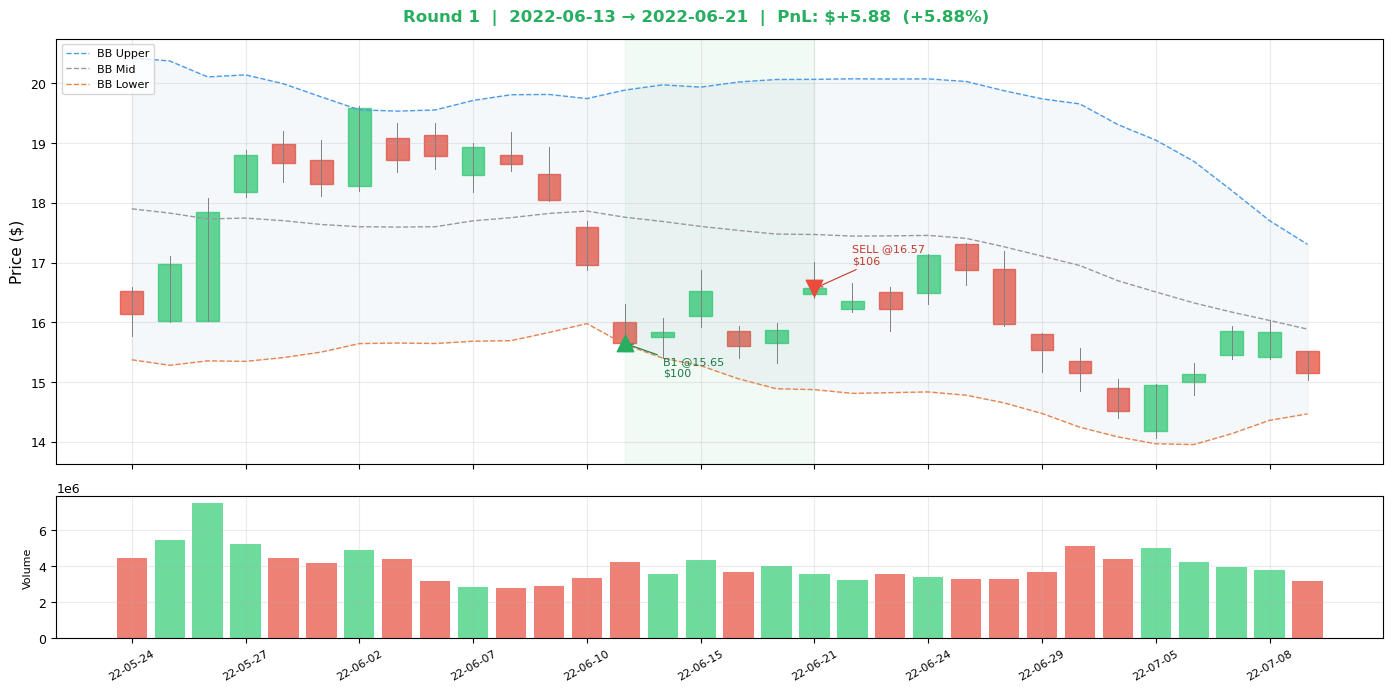

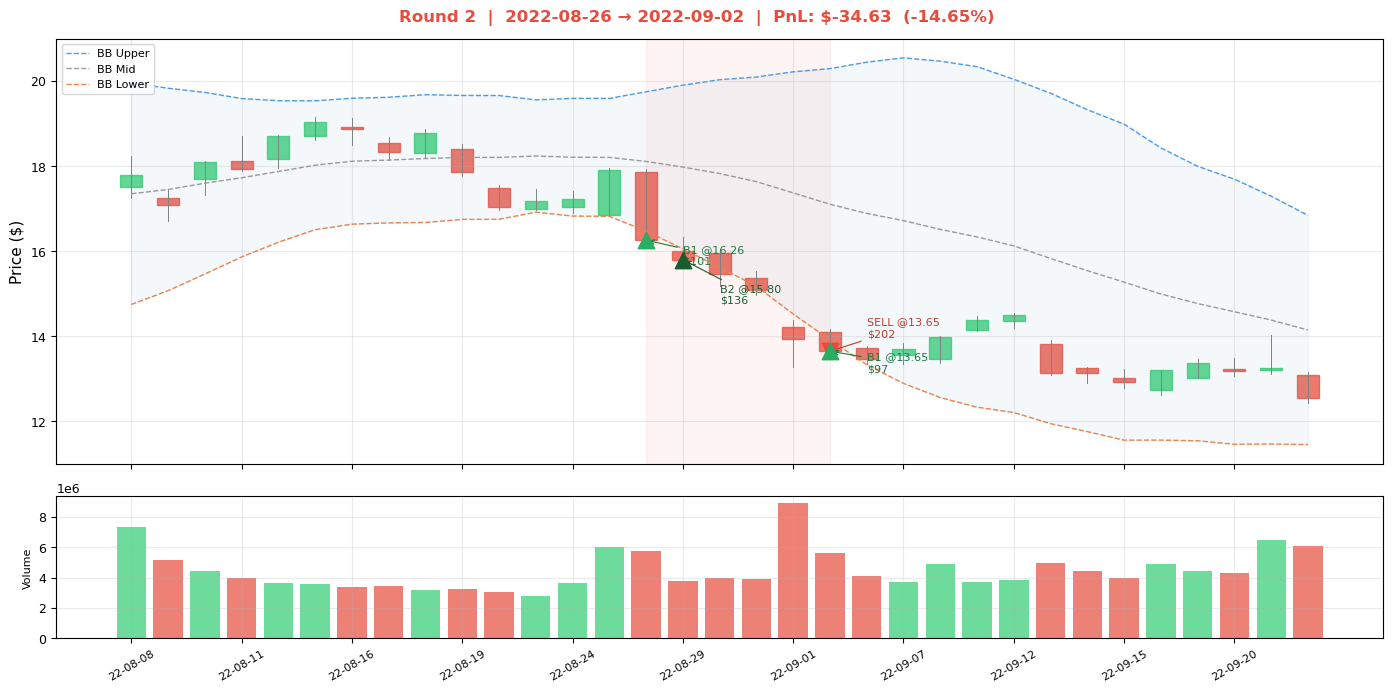

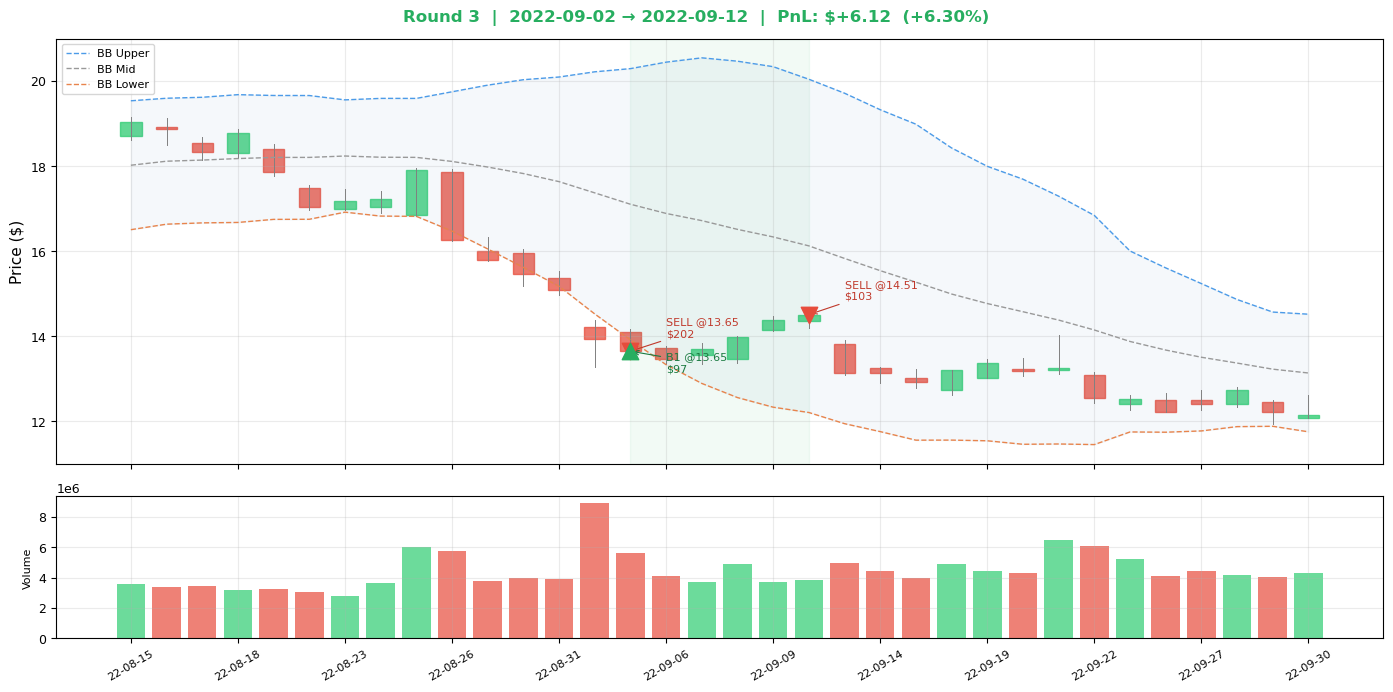

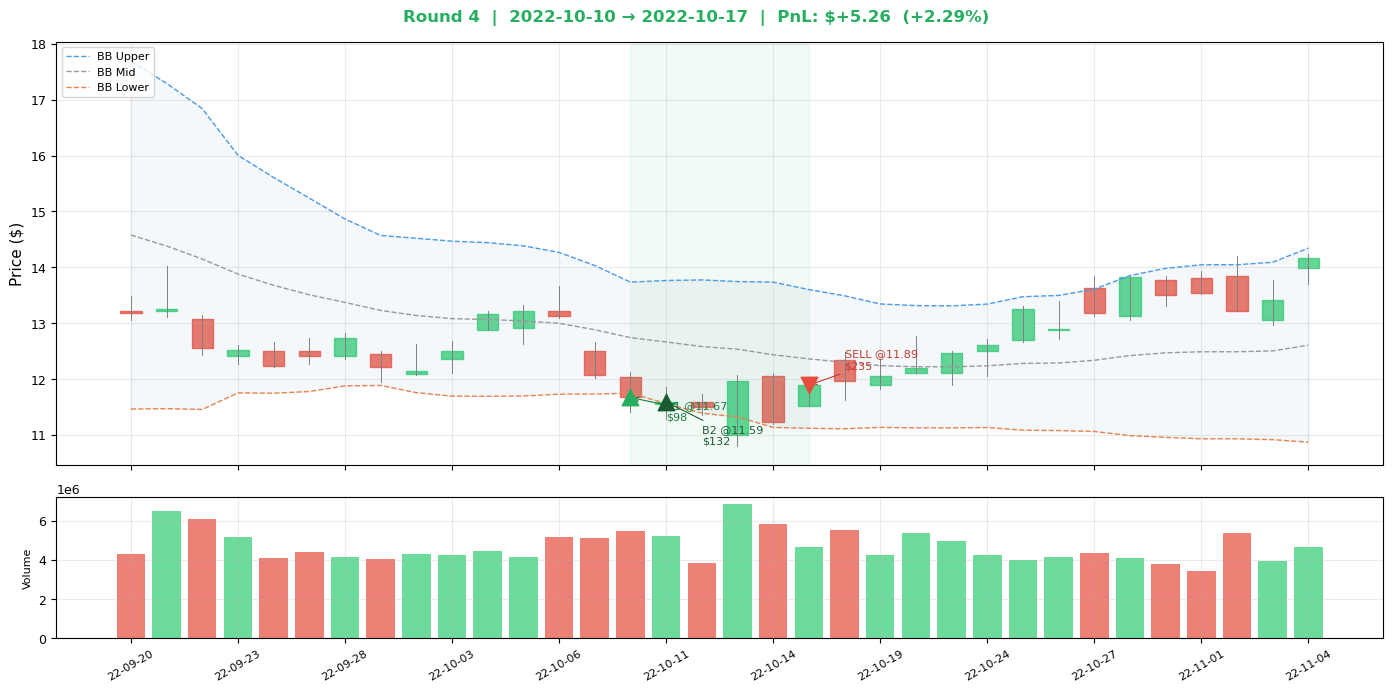

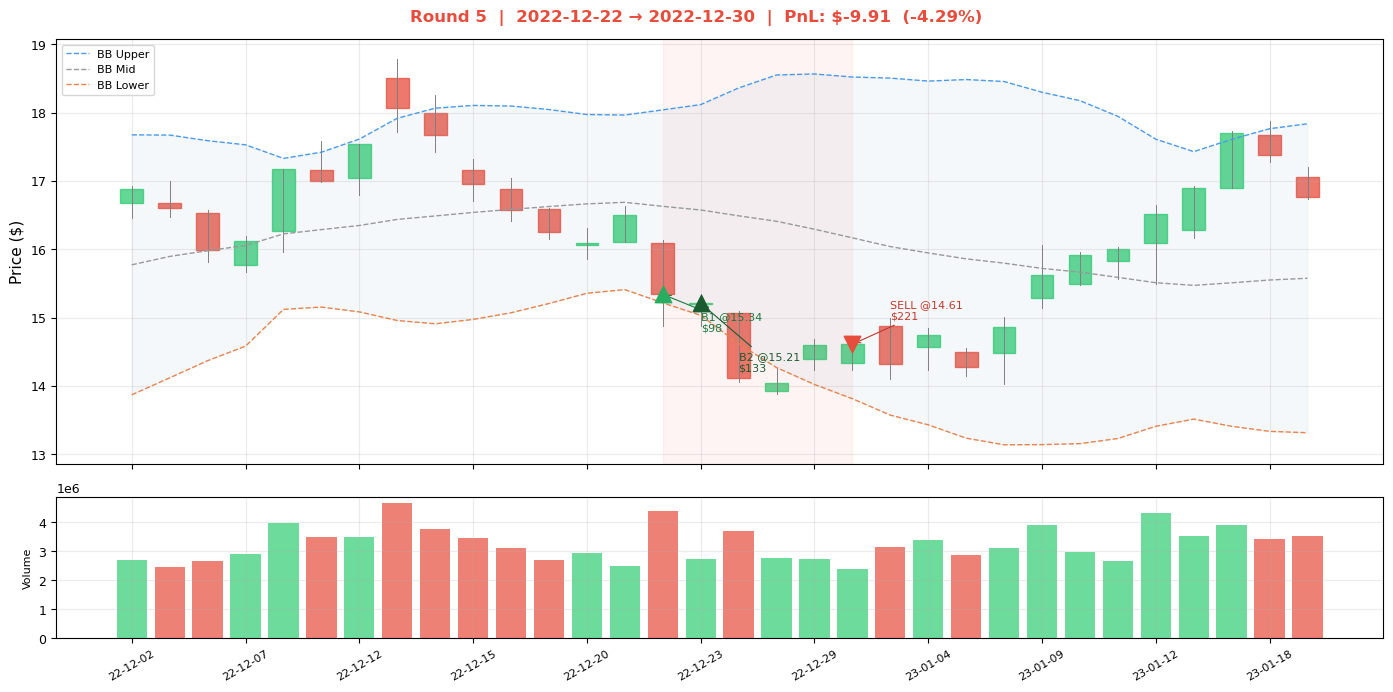

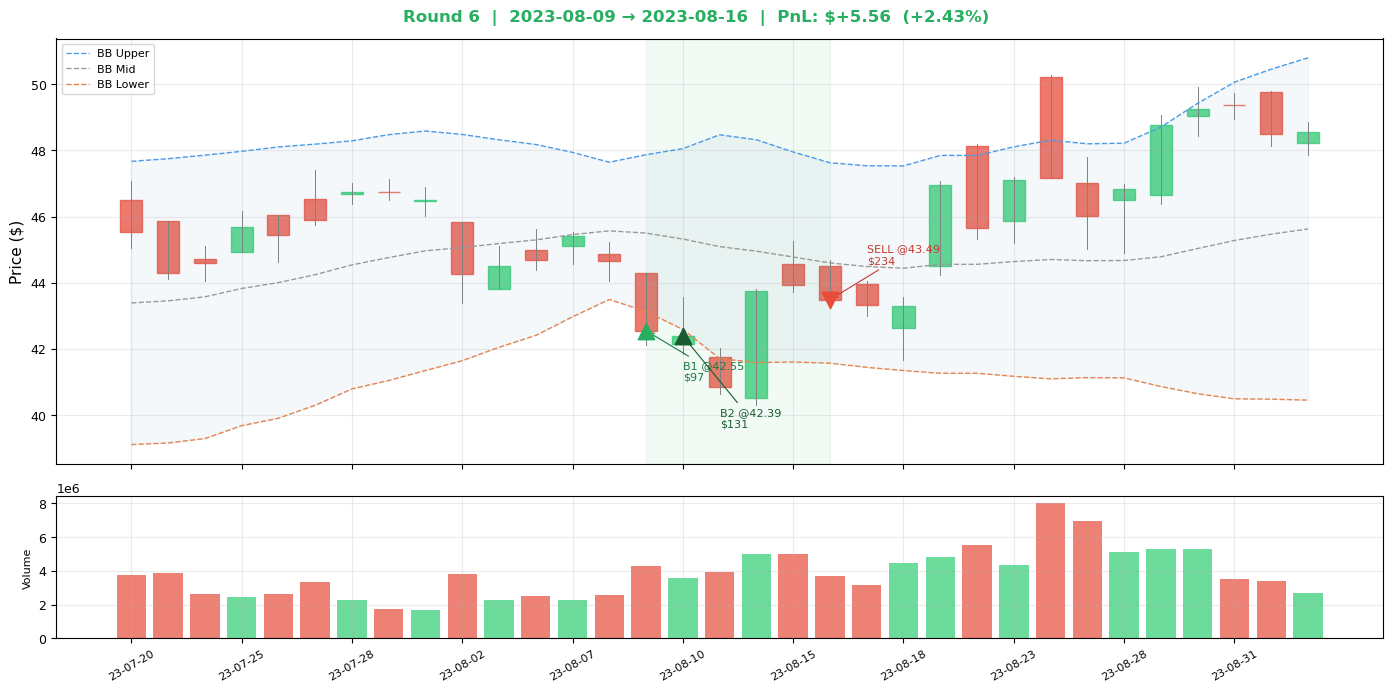

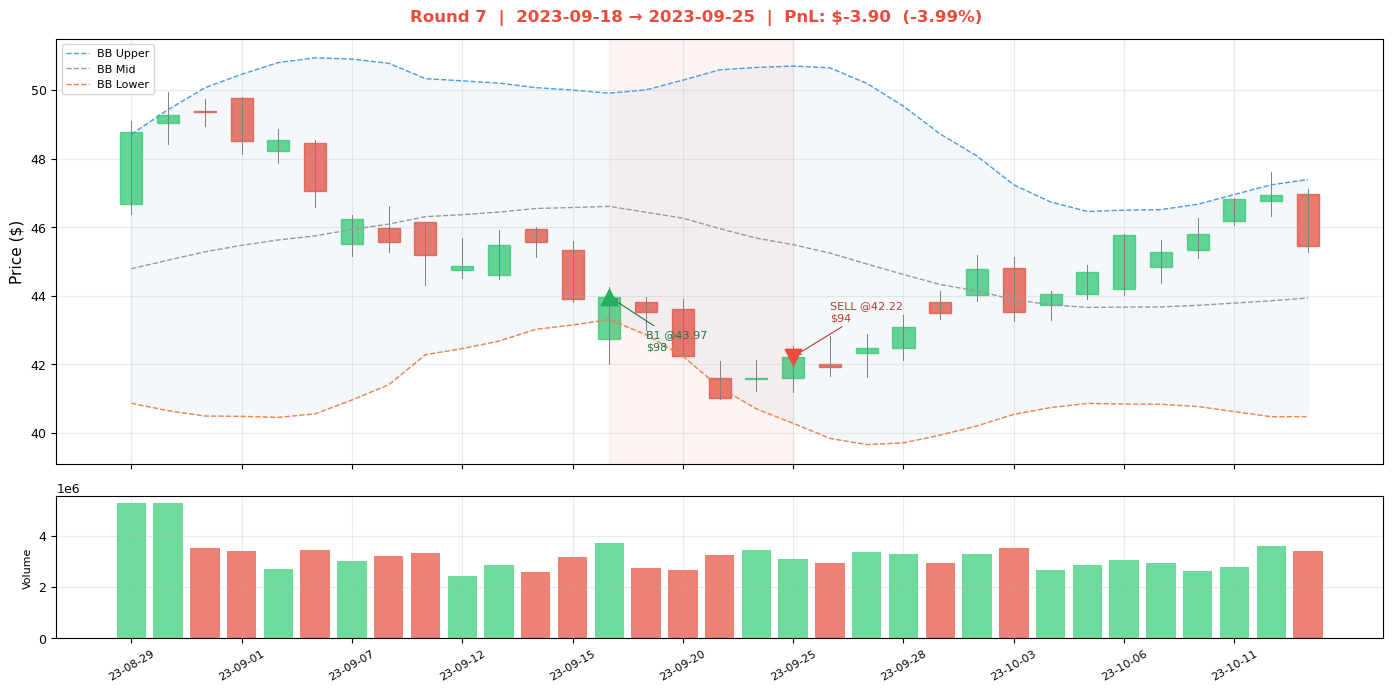

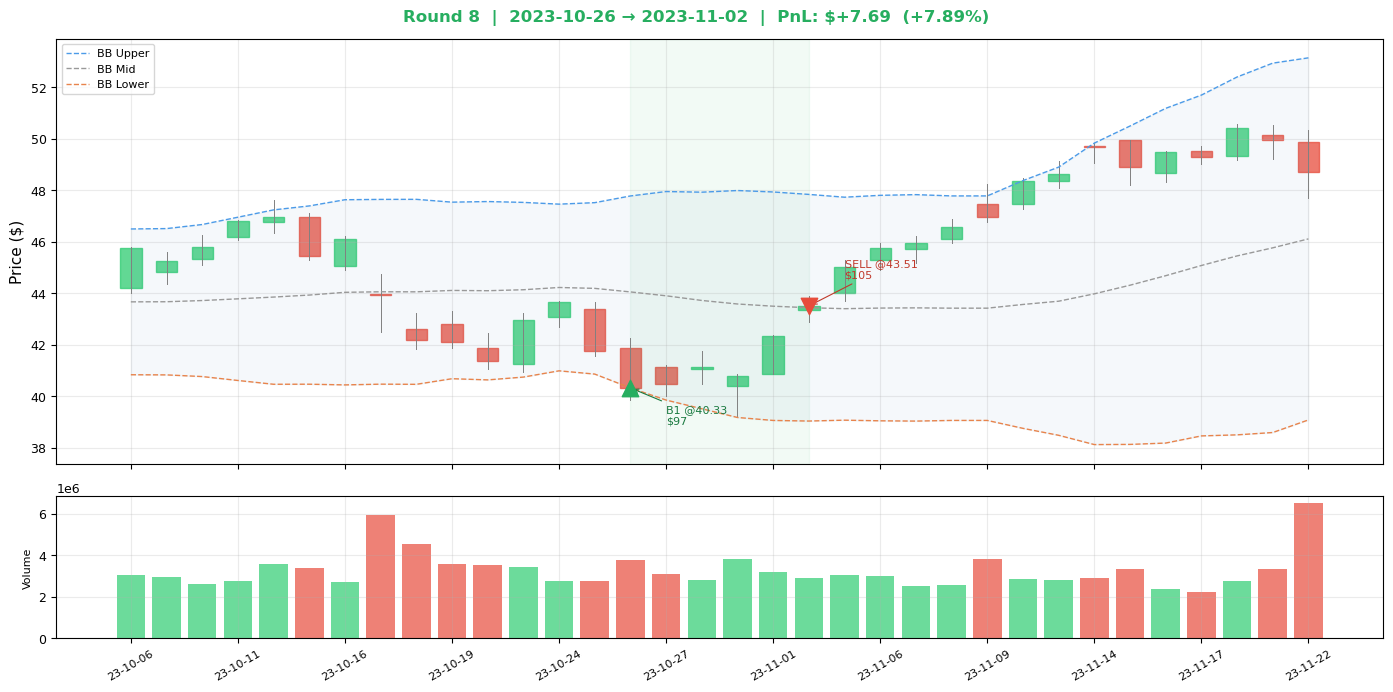

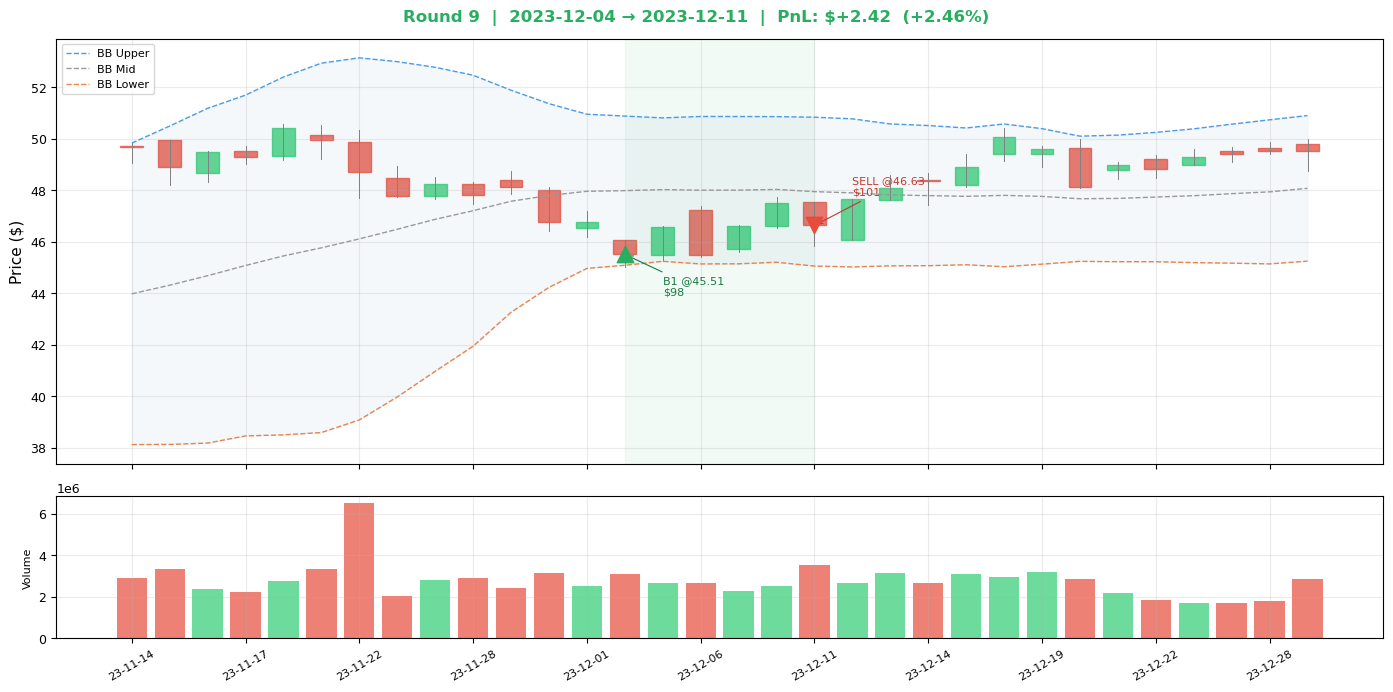

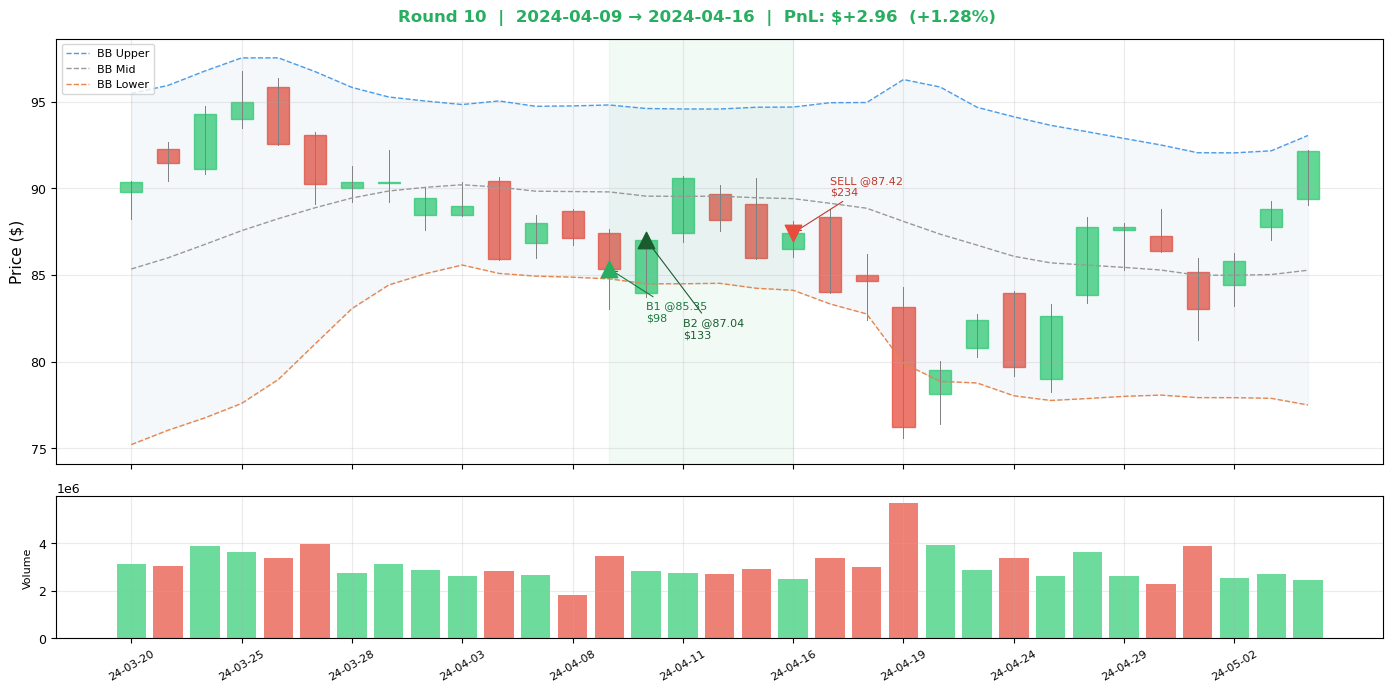

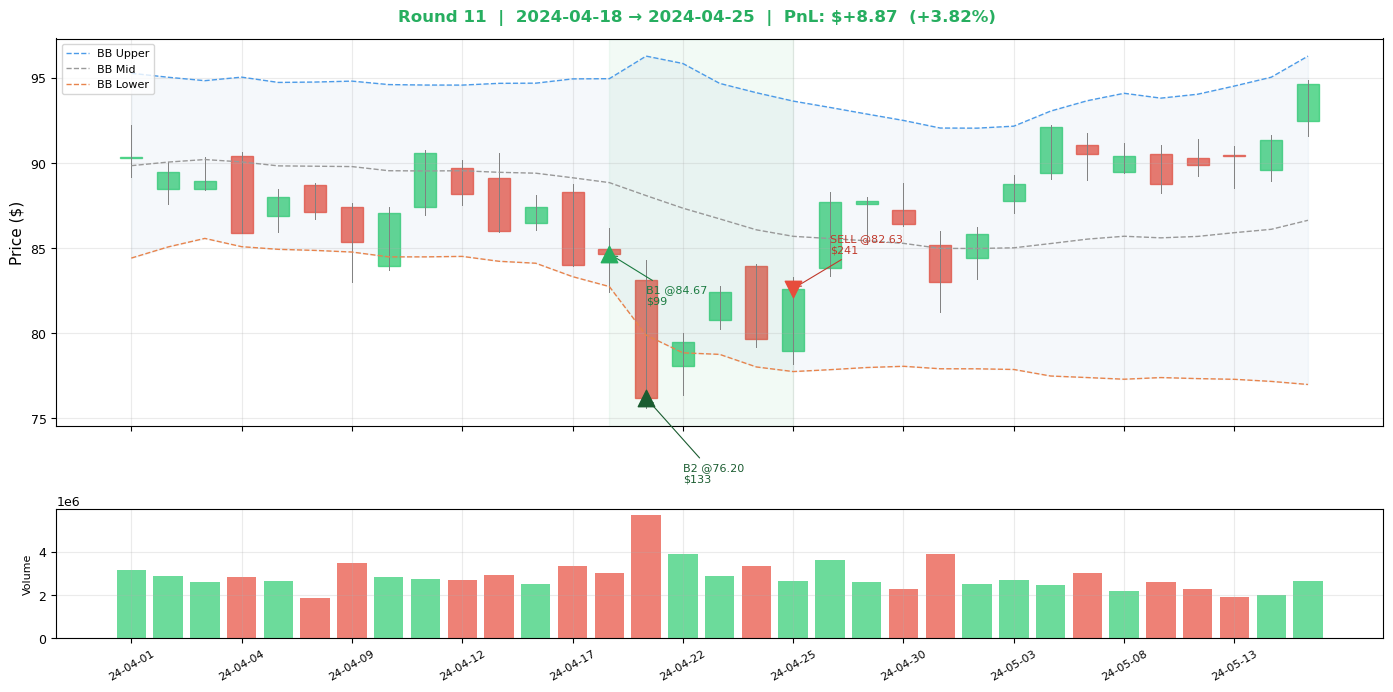

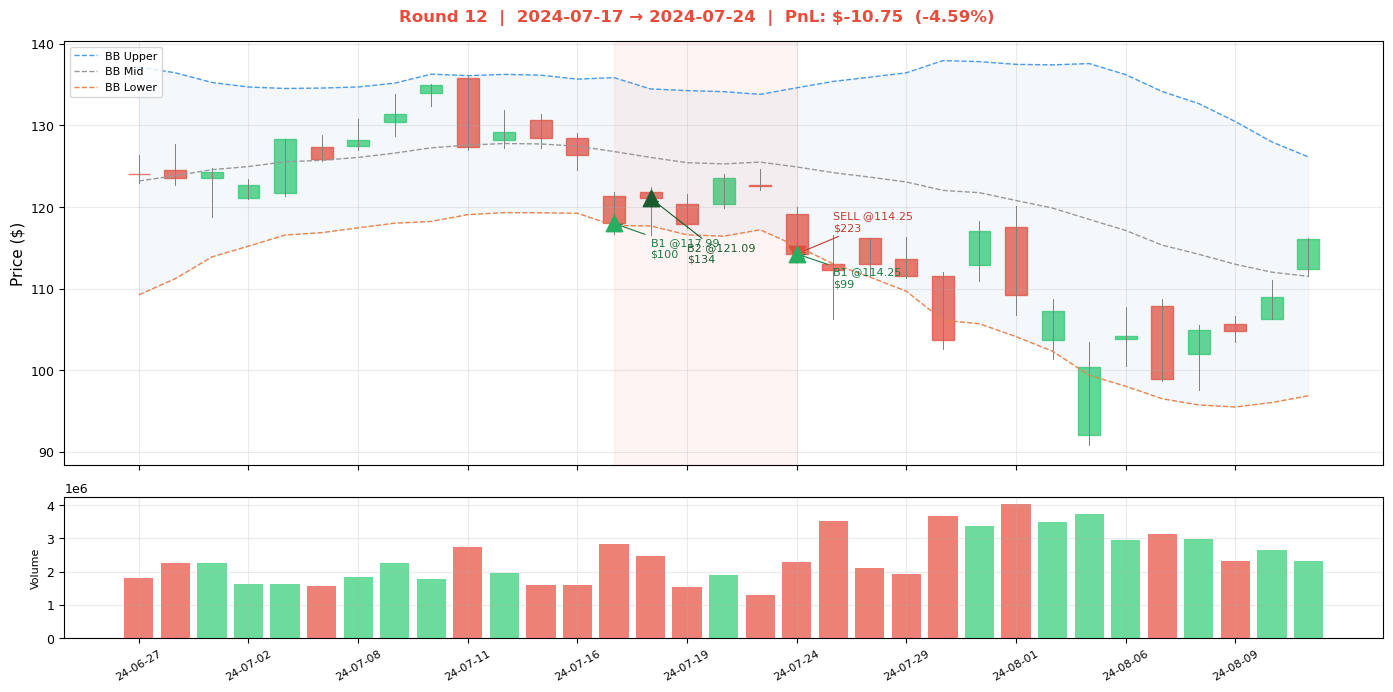

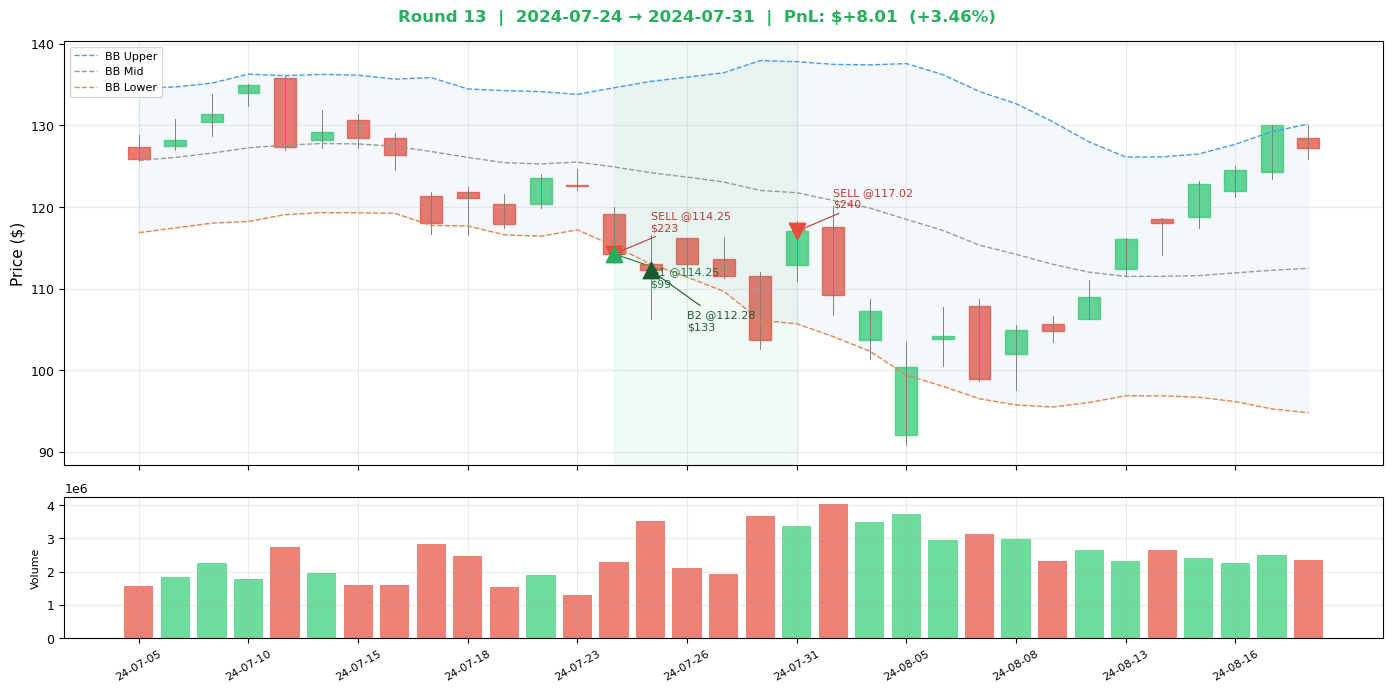

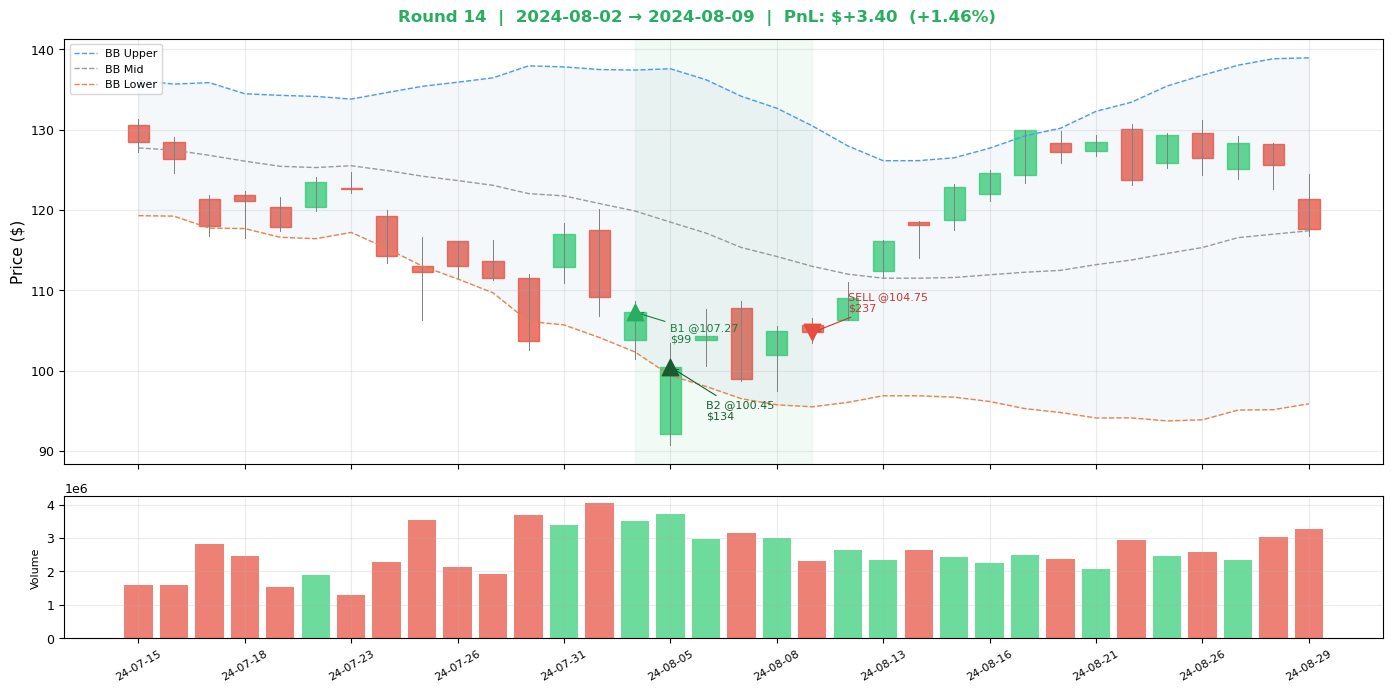

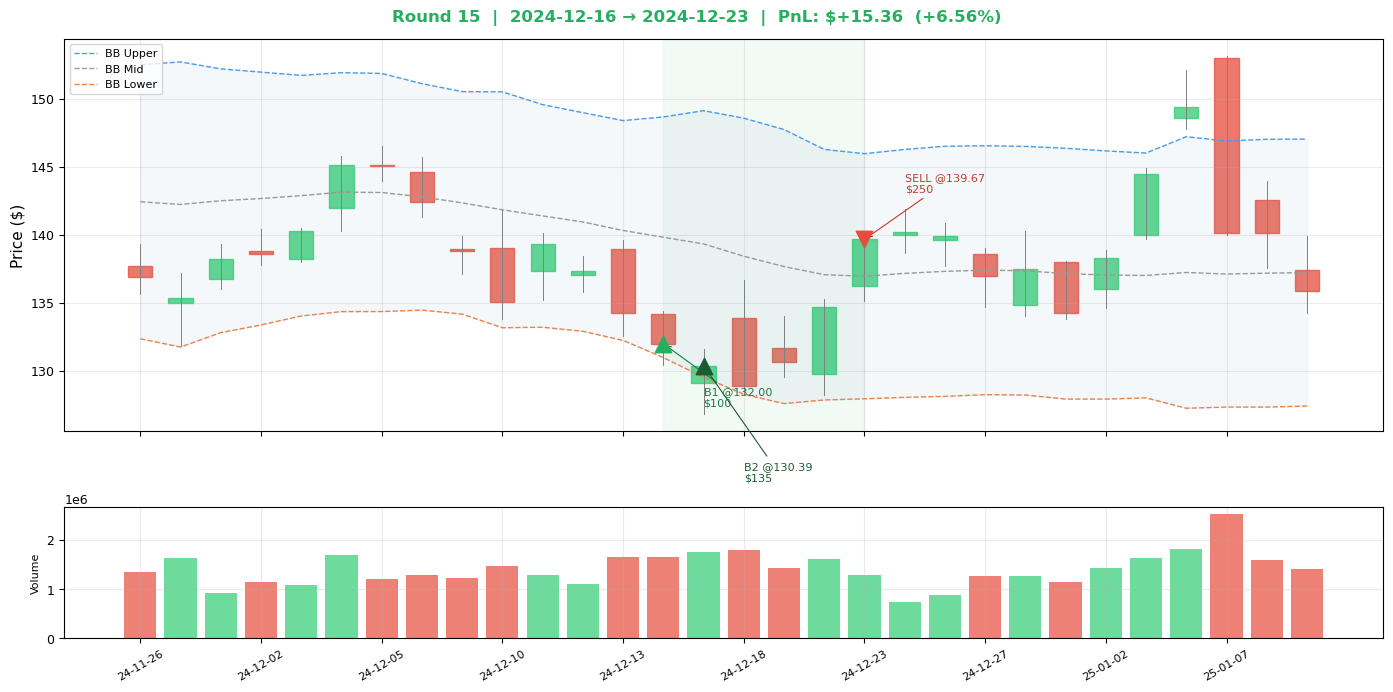

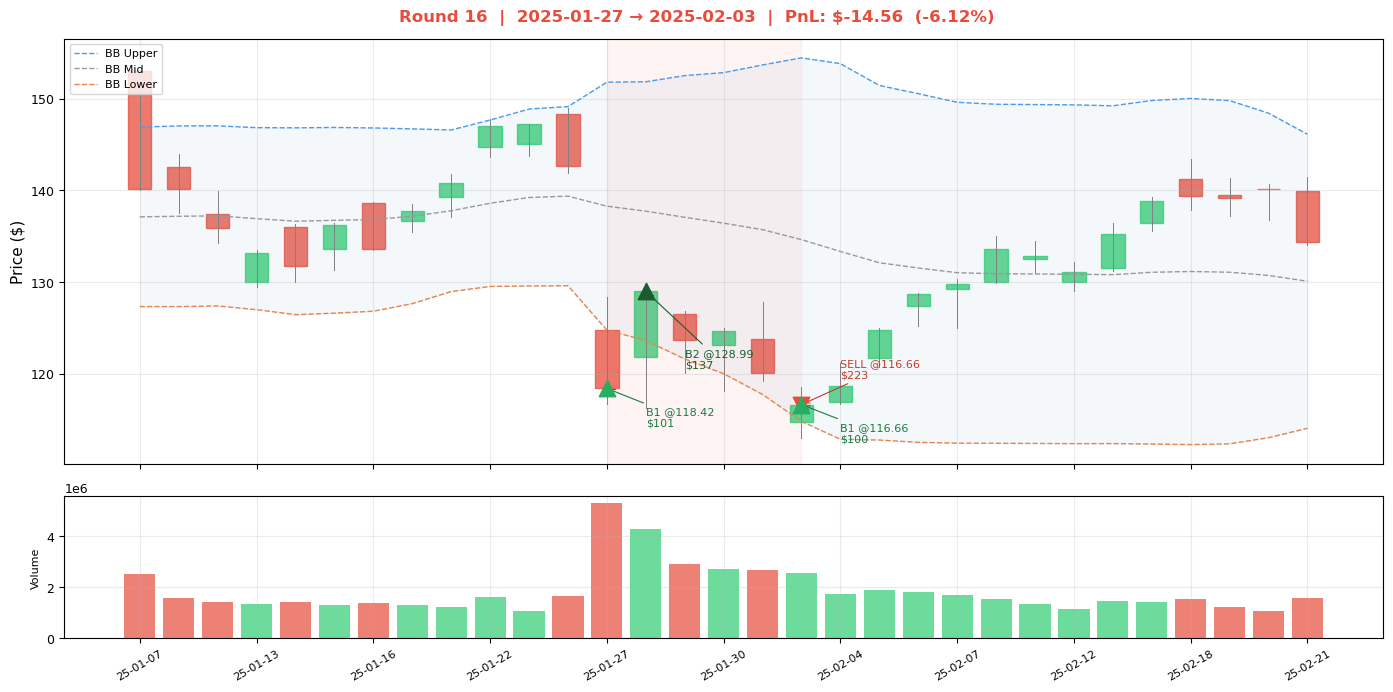

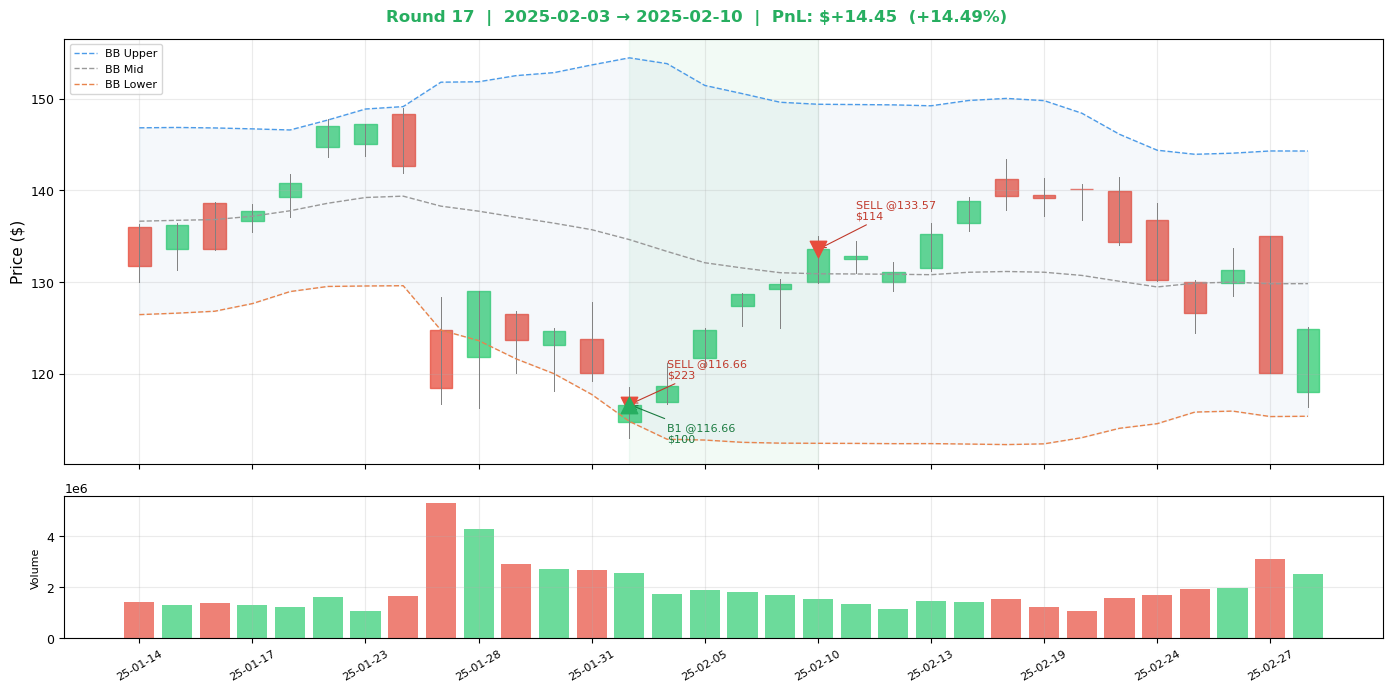

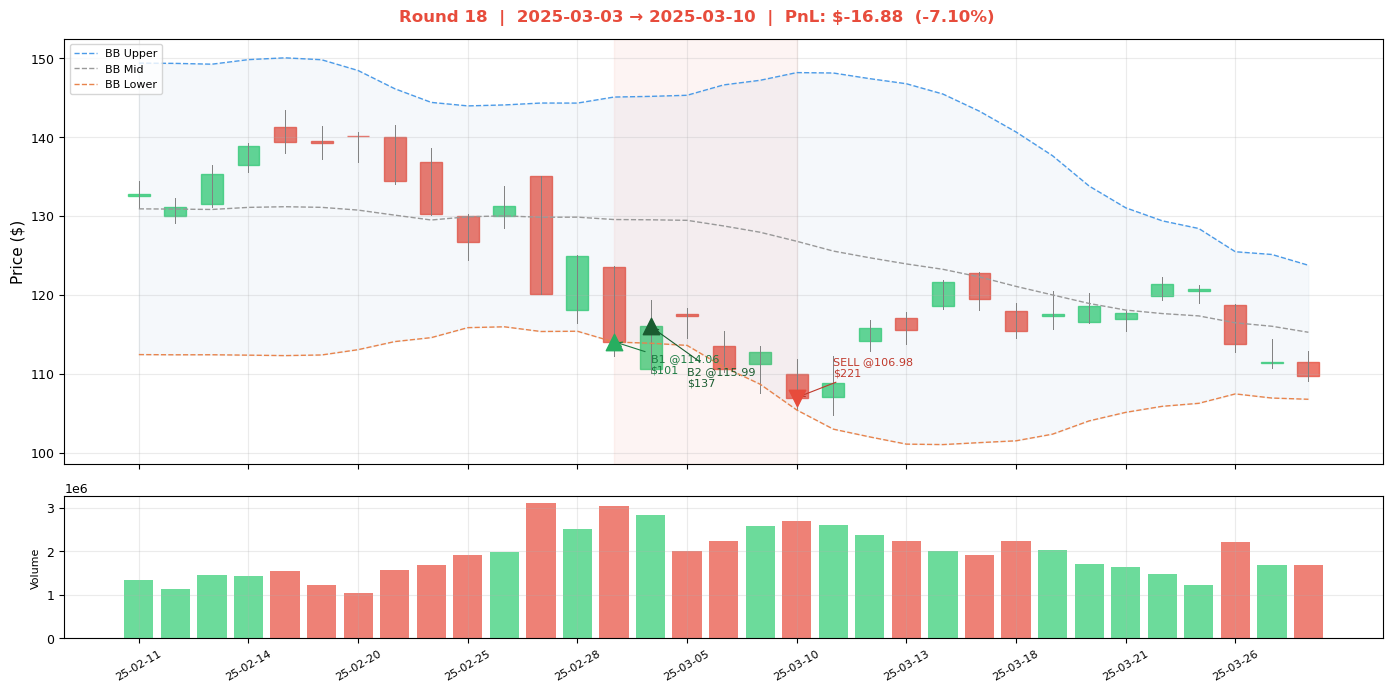

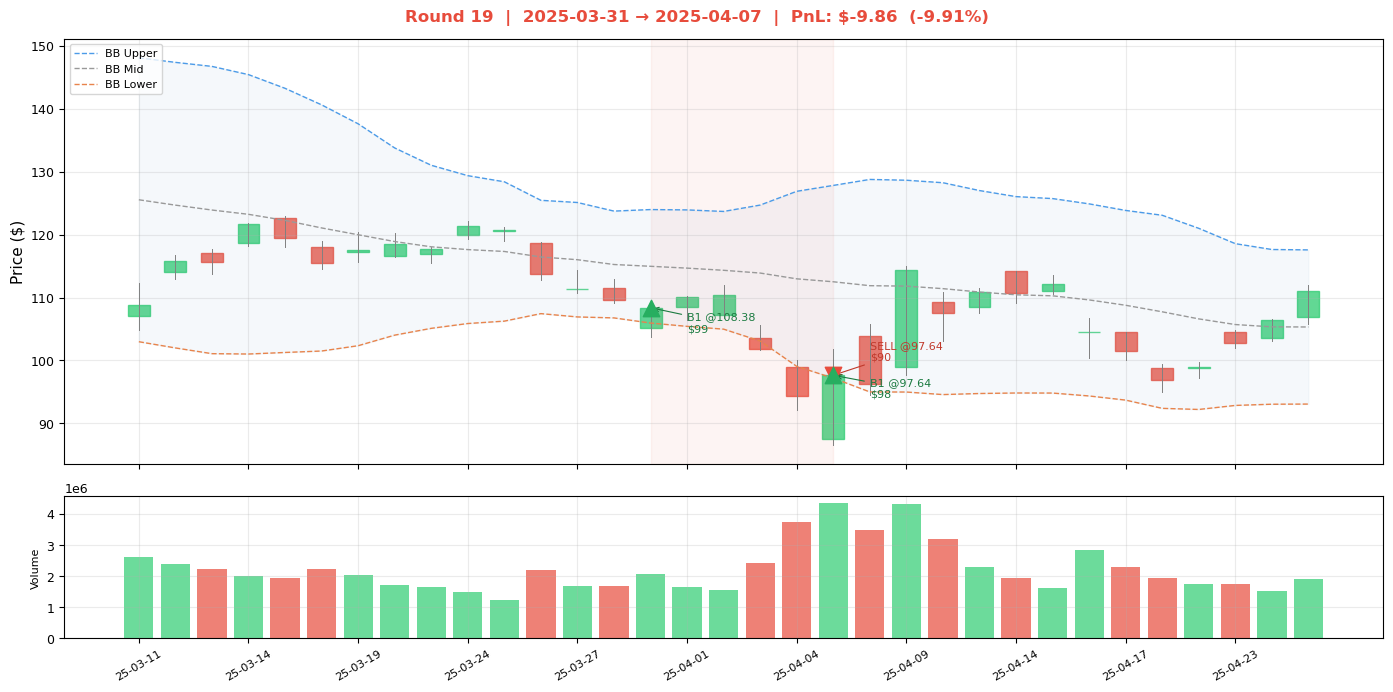

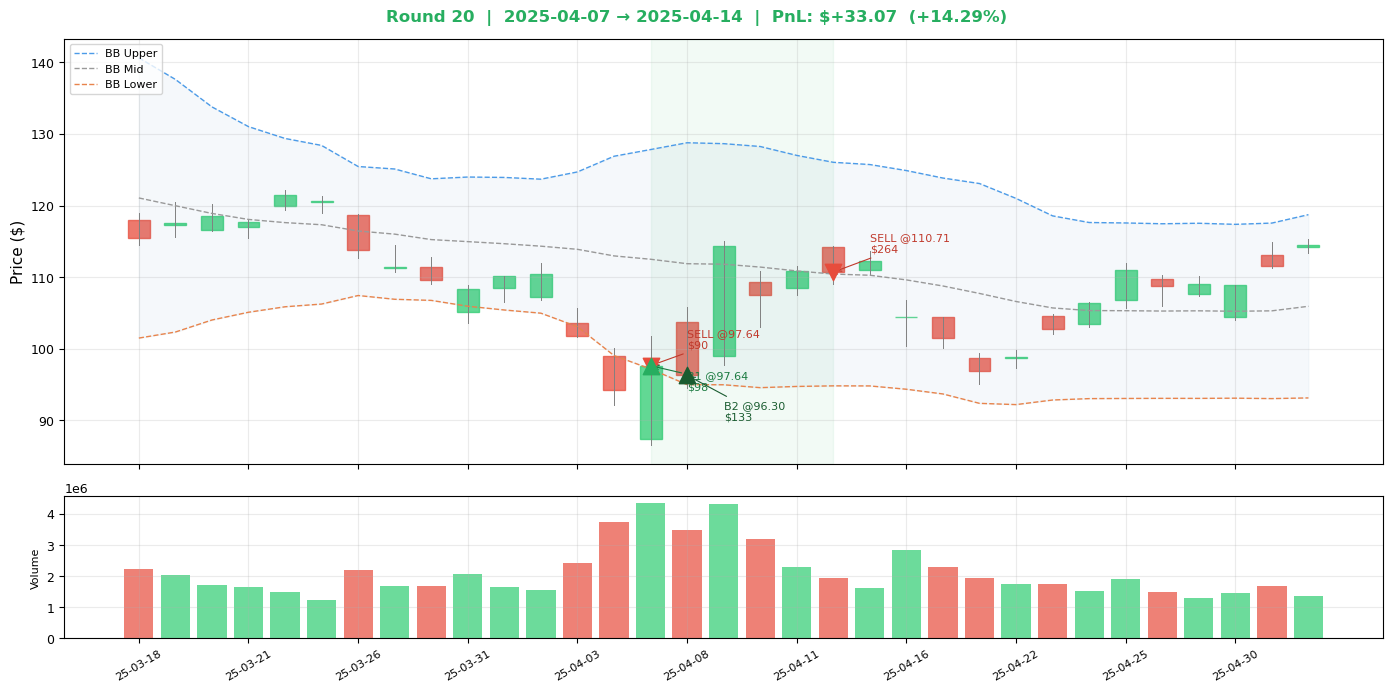

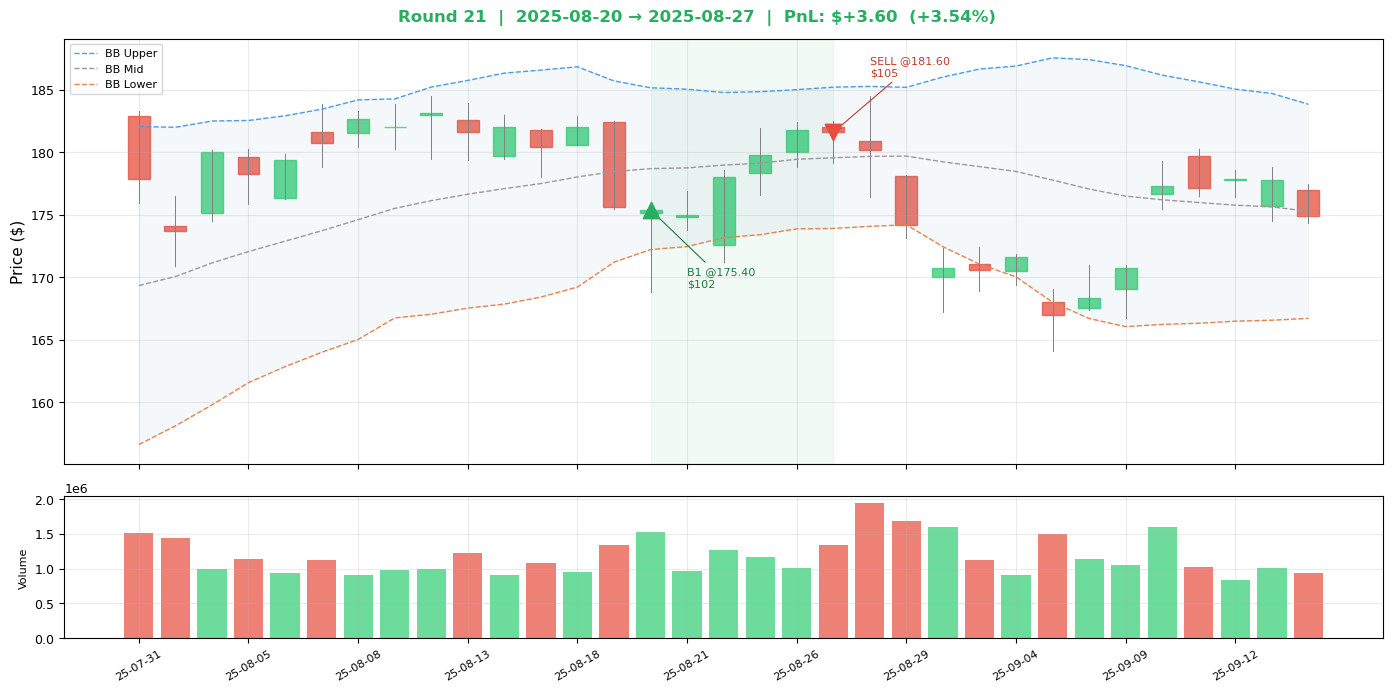

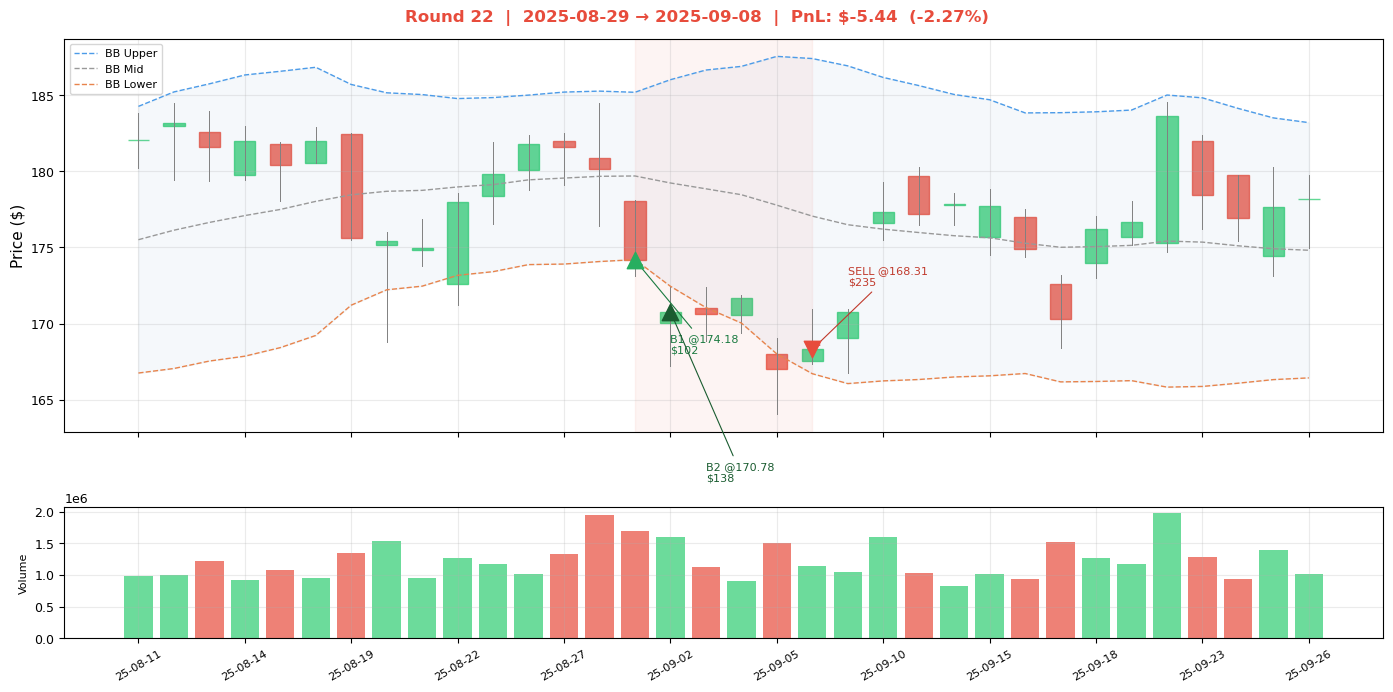

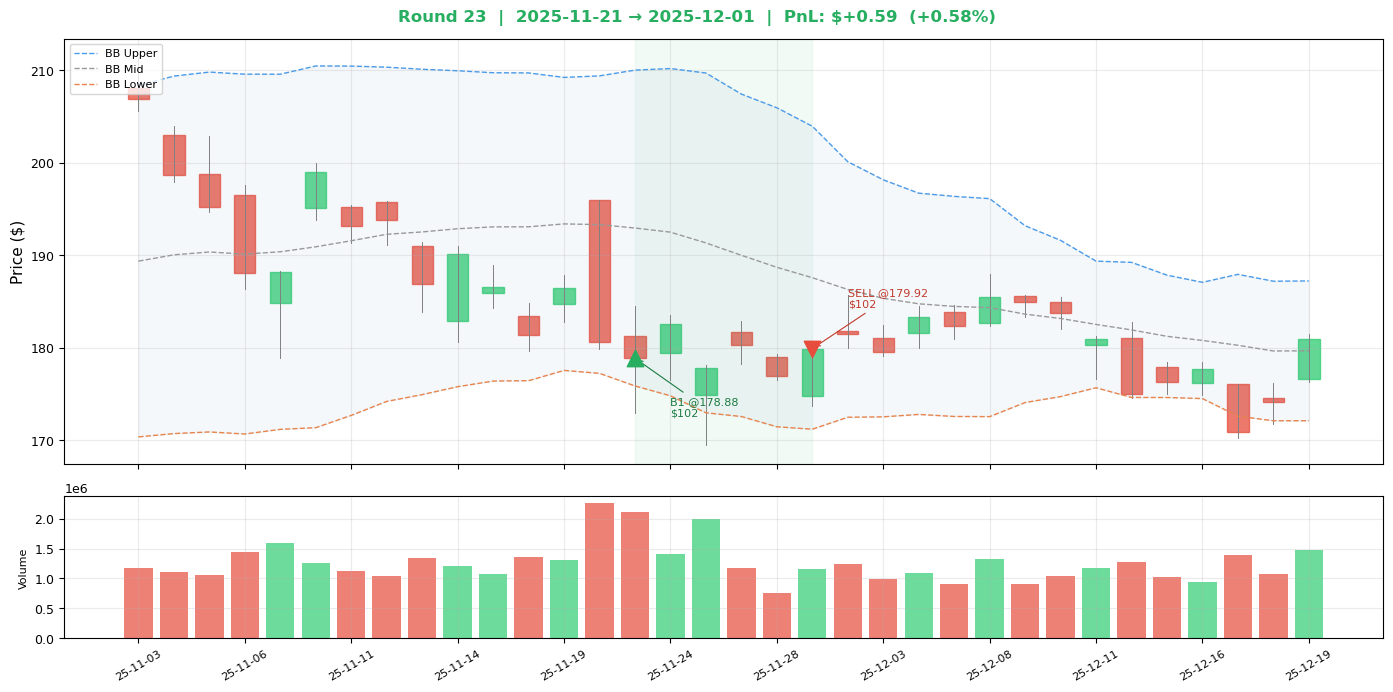

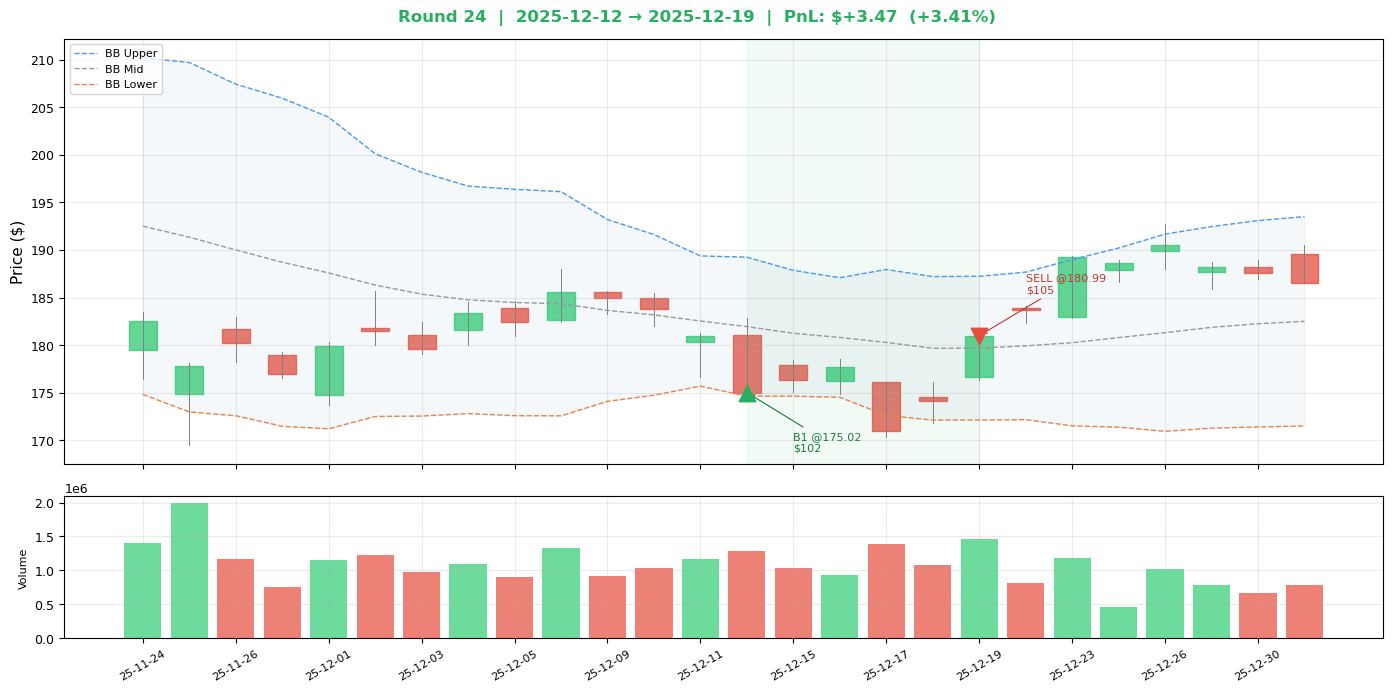

In [19]:
def plot_trade_detail(df, trades_df, rdf, pad_days=14):
    """
    每轮买卖画一张图：
      - K线 + 布林带
      - 成交量（下方子图）
      - 买入/卖出标注（价格 + 金额）
      - 窗口：首次买入前 pad_days 天 ~ 卖出后 pad_days 天
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    trades_df = trades_df.copy()
    trades_df['date'] = pd.to_datetime(trades_df['date'])

    for idx, r in rdf.iterrows():
        buy_date  = pd.Timestamp(r['buy_date'])
        sell_date = pd.Timestamp(r['sell_date'])

        # ── 窗口切片 ──────────────────────────────────
        win_start = buy_date  - pd.offsets.BDay(pad_days)
        win_end   = sell_date + pd.offsets.BDay(pad_days)
        chunk = df.loc[win_start:win_end].copy()
        if len(chunk) < 3:
            continue

        x         = np.arange(len(chunk))
        dates     = chunk.index.tolist()
        date_to_x = {d: i for i, d in enumerate(dates)}

        # ── 布局 ──────────────────────────────────────
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(14, 7), sharex=True,
            gridspec_kw={'height_ratios': [3, 1]}
        )
        pnl_color = '#27AE60' if r['PnL ($)'] >= 0 else '#E74C3C'
        fig.suptitle(
            f"Round {idx+1}  |  {r['buy_date']} → {r['sell_date']}  "
            f"|  PnL: ${r['PnL ($)']:+.2f}  ({r['PnL (%)']:+.2f}%)",
            fontsize=12, color=pnl_color, fontweight='bold'
        )

        # ── K线 ───────────────────────────────────────
        for i, (dt, row) in enumerate(chunk.iterrows()):
            o, c, h, l = row['open'], row['close'], row['high'], row['low']
            color = '#2ECC71' if c >= o else '#E74C3C'
            ax1.plot([i, i], [l, h], color='gray', lw=0.7)
            ax1.add_patch(plt.Rectangle(
                (i - 0.3, min(o, c)), 0.6, max(abs(c - o), 0.01),
                color=color, alpha=0.75
            ))

        # ── 布林带 ────────────────────────────────────
        ax1.plot(x, chunk['bb_upper'], color='#4C9BE8', lw=1, ls='--', label='BB Upper')
        ax1.plot(x, chunk['bb_mid'],   color='#999',    lw=1, ls='--', label='BB Mid')
        ax1.plot(x, chunk['bb_lower'], color='#E8844C', lw=1, ls='--', label='BB Lower')
        ax1.fill_between(x, chunk['bb_lower'], chunk['bb_upper'],
                         alpha=0.05, color='steelblue')

        # ── 买卖区间背景 ──────────────────────────────
        if buy_date in date_to_x and sell_date in date_to_x:
            ax1.axvspan(date_to_x[buy_date], date_to_x[sell_date],
                        alpha=0.06, color=pnl_color)

        # ── 买卖标注 ──────────────────────────────────
        round_trades = trades_df[
            (trades_df['date'] >= buy_date) & (trades_df['date'] <= sell_date)
        ]
        for _, t in round_trades.iterrows():
            td = t['date'].normalize()
            xi = date_to_x.get(td)
            if xi is None:
                for d, xi_try in date_to_x.items():
                    if abs((d - td).days) <= 1:
                        xi = xi_try
                        break
            if xi is None:
                continue

            if t['action'] == 'BUY_1 (10%)':
                ax1.scatter(xi, t['price'], marker='^', color='#27AE60', s=140, zorder=6)
                ax1.annotate(
                    f"B1 @{t['price']:.2f}\n${t['value']:,.0f}",
                    xy=(xi, t['price']),
                    xytext=(xi + 1, t['price'] * 0.965),
                    fontsize=8, color='#1A7A40',
                    arrowprops=dict(arrowstyle='->', color='#1A7A40', lw=0.8)
                )
            elif t['action'] == 'BUY_2 (15%)':
                ax1.scatter(xi, t['price'], marker='^', color='#1A5C30', s=140, zorder=6)
                ax1.annotate(
                    f"B2 @{t['price']:.2f}\n${t['value']:,.0f}",
                    xy=(xi, t['price']),
                    xytext=(xi + 1, t['price'] * 0.935),
                    fontsize=8, color='#1A5C30',
                    arrowprops=dict(arrowstyle='->', color='#1A5C30', lw=0.8)
                )
            elif t['action'] == 'SELL':
                ax1.scatter(xi, t['price'], marker='v', color='#E74C3C', s=140, zorder=6)
                ax1.annotate(
                    f"SELL @{t['price']:.2f}\n${t['value']:,.0f}",
                    xy=(xi, t['price']),
                    xytext=(xi + 1, t['price'] * 1.025),
                    fontsize=8, color='#C0392B',
                    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=0.8)
                )

        ax1.set_ylabel('Price ($)')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.grid(True, alpha=0.25)

        # ── 成交量 ────────────────────────────────────
        vol_colors = ['#2ECC71' if chunk['close'].iloc[i] >= chunk['open'].iloc[i]
                      else '#E74C3C' for i in range(len(chunk))]
        ax2.bar(x, chunk['volume'].values, color=vol_colors, alpha=0.7)
        ax2.set_ylabel('Volume', fontsize=8)
        ax2.grid(True, alpha=0.25)

        # ── X 轴日期 ──────────────────────────────────
        step = max(1, len(dates) // 10)
        ax2.set_xticks(x[::step])
        ax2.set_xticklabels(
            [dates[i].strftime('%y-%m-%d') for i in x[::step]],
            rotation=30, fontsize=8
        )

        plt.tight_layout()
        # plt.savefig(f'trade_{SYMBOL}_round{idx+1}.png', dpi=130, bbox_inches='tight')
        plt.show()


plot_trade_detail(df, trades_df, rdf, pad_days=14)

In [15]:
def perf_stats(equity, periods_per_year=252):
    eq    = equity.dropna()
    ret   = eq.pct_change().fillna(0.0)
    years = (len(eq) - 1) / periods_per_year
    cagr  = (eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1 if years > 0 else float('nan')
    vol   = ret.std(ddof=0)
    sharpe  = ret.mean() / vol * np.sqrt(periods_per_year) if vol > 0 else float('nan')
    maxdd   = float((eq / eq.cummax() - 1).min())
    calmar  = cagr / abs(maxdd) if maxdd < 0 else float('nan')
    s = {
        'Init Cash':    f'${INIT_CASH:,.0f}',
        'Final Equity': f'${eq.iloc[-1]:,.2f}',
        'CAGR':         f'{cagr:.2%}',
        'Sharpe':       f'{sharpe:.2f}',
        'Max Drawdown': f'{maxdd:.2%}',
        'Calmar':       f'{calmar:.2f}',
        'Total Trades': len(trades_df),
    }
    for k, v in s.items():
        print(f'{k:>15}: {v}')
    return s

s = perf_stats(res['equity'])
s

      Init Cash: $1,000
   Final Equity: $1,019.93
           CAGR: 0.55%
         Sharpe: 0.14
   Max Drawdown: -4.17%
         Calmar: 0.13
   Total Trades: 62


{'Init Cash': '$1,000',
 'Final Equity': '$1,019.93',
 'CAGR': '0.55%',
 'Sharpe': '0.14',
 'Max Drawdown': '-4.17%',
 'Calmar': '0.13',
 'Total Trades': 62}

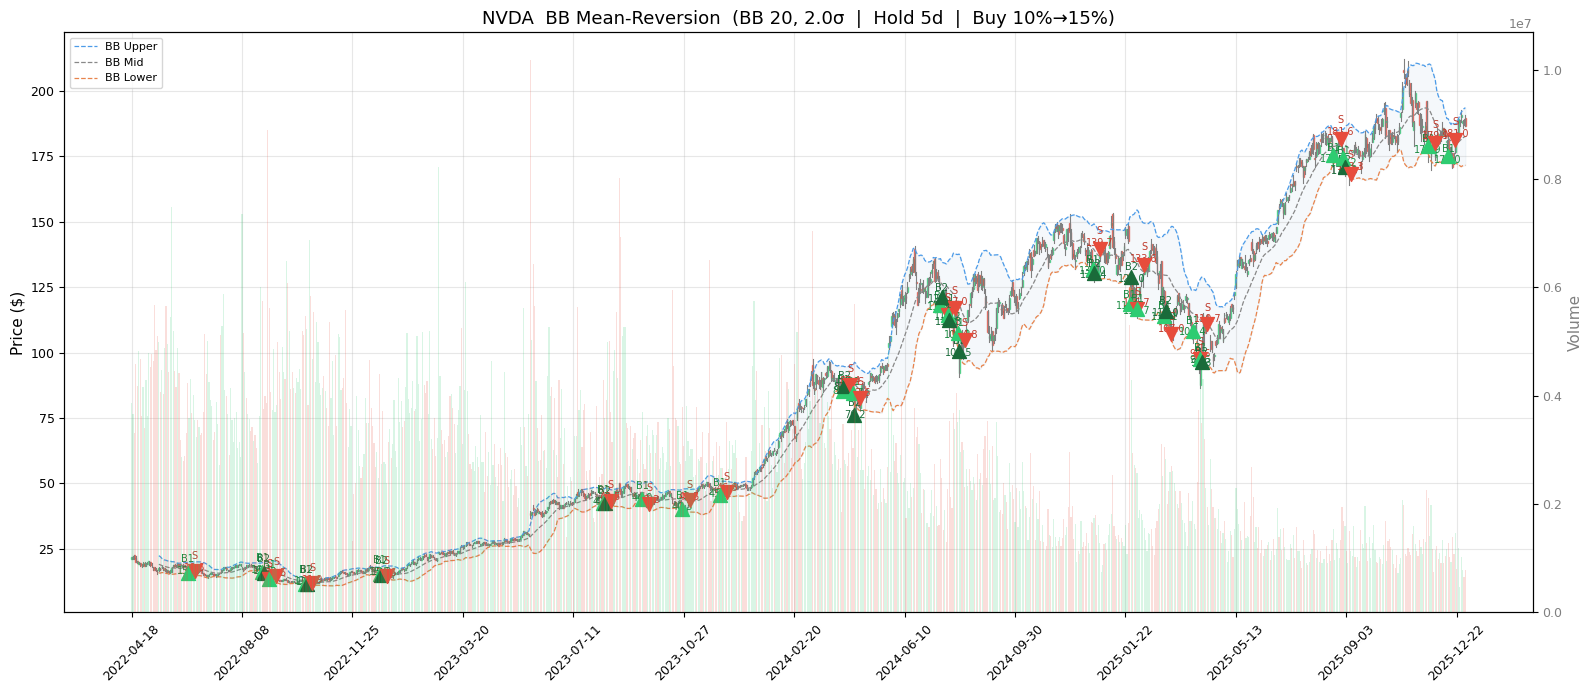

KeyError: 'position'

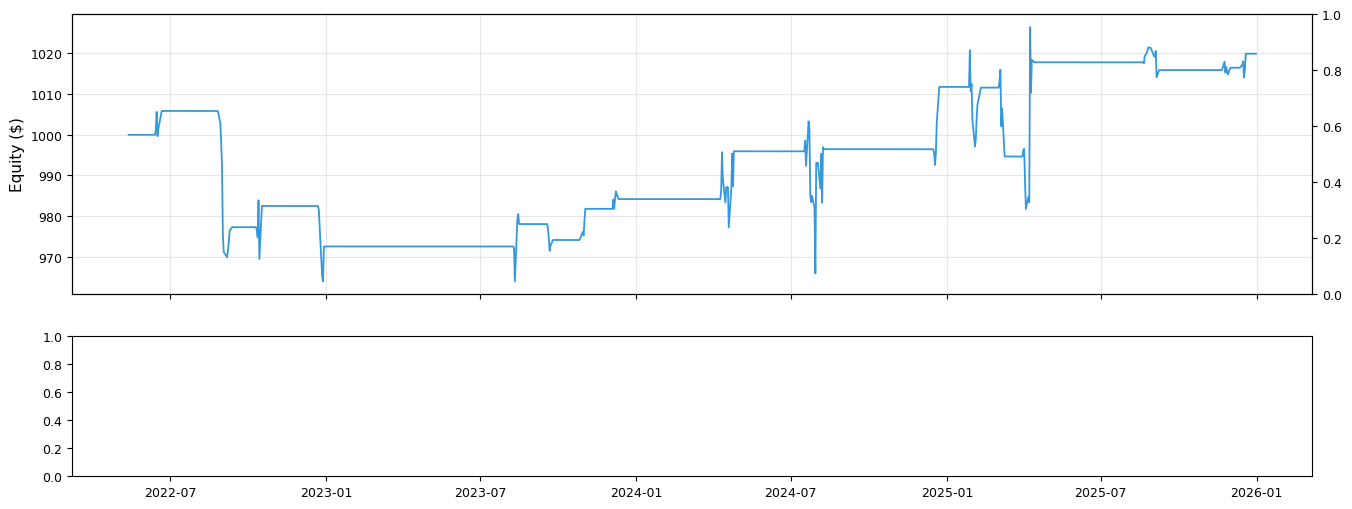

In [ ]:
def plot_bb_ohlc(df, res, trades_df, symbol, start=None, end=None, figuresize=(16, 7)):
    """价格K线 + 布林带 + 成交量 + 买卖点"""
    df = df.copy()
    df.index = pd.to_datetime(df['date'])
    if start: df = df.loc[start:]
    if end:   df = df.loc[:end]

    fig, ax1 = plt.subplots(figsize=figuresize)
    plt.rcParams.update({'font.size': 9, 'axes.titlesize': 13, 'axes.labelsize': 11})
    x = np.arange(len(df))
    dates = df.index.tolist()
    date_to_x = {d: i for i, d in enumerate(dates)}

    # ── K线 ───────────────────────────────────────────
    for i, (_, row) in enumerate(df.iterrows()):
        o, c, h, l = row['open'], row['close'], row['high'], row['low']
        color = '#2ECC71' if c >= o else '#E74C3C'
        ax1.plot([i, i], [l, h], color='gray', lw=0.8)
        ax1.add_patch(plt.Rectangle((i - 0.3, min(o, c)), 0.6,
                      max(abs(c - o), 0.01), color=color, alpha=0.7))

    # ── 布林带 ────────────────────────────────────────
    bb = res.copy()
    bb.index = pd.to_datetime(bb['date'])
    if start: bb = bb.loc[start:]
    if end:   bb = bb.loc[:end]
    bx = [date_to_x[d] for d in bb.index if d in date_to_x]
    n  = len(bx)
    ax1.plot(bx, bb['bb_upper'].values[:n], color='#4C9BE8', lw=0.9, ls='--', label='BB Upper')
    ax1.plot(bx, bb['bb_mid'].values[:n],   color='#888',    lw=0.9, ls='--', label='BB Mid')
    ax1.plot(bx, bb['bb_lower'].values[:n], color='#E8844C', lw=0.9, ls='--', label='BB Lower')
    ax1.fill_between(bx, bb['bb_lower'].values[:n], bb['bb_upper'].values[:n],
                     alpha=0.05, color='steelblue')

    # ── 买卖点 ────────────────────────────────────────
    for _, t in trades_df.iterrows():
        td = pd.Timestamp(t['date'])
        if td not in date_to_x:
            continue
        xi = date_to_x[td]
        if t['action'] == 'BUY_1 (10%)':
            ax1.scatter(xi, t['price'], marker='^', color='#2ECC71', s=100, zorder=5)
            ax1.text(xi, t['price'] * 0.984, f"B1\n{t['price']:.1f}",
                     fontsize=7, color='#1A8A40', ha='center')
        elif t['action'] == 'BUY_2 (15%)':
            ax1.scatter(xi, t['price'], marker='^', color='#1A6B3A', s=100, zorder=5)
            ax1.text(xi, t['price'] * 0.984, f"B2\n{t['price']:.1f}",
                     fontsize=7, color='#1A6B3A', ha='center')
        elif t['action'] == 'SELL':
            ax1.scatter(xi, t['price'], marker='v', color='#E74C3C', s=100, zorder=5)
            ax1.text(xi, t['price'] * 1.008, f"S\n{t['price']:.1f}",
                     fontsize=7, color='#C0392B', ha='center')

    # ── X轴 + 成交量 ─────────────────────────────────
    step = max(1, len(dates) // 12)
    ax1.set_xticks(x[::step])
    ax1.set_xticklabels([dates[i].strftime('%Y-%m-%d') for i in x[::step]], rotation=45)
    ax1.set_ylabel('Price ($)')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    vol_colors = ['#2ECC71' if df['close'].iloc[i] >= df['open'].iloc[i] else '#E74C3C'
                  for i in range(len(df))]
    ax2.bar(x, df['volume'].values, alpha=0.18, color=vol_colors)
    ax2.set_ylabel('Volume', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    plt.title(f'{symbol}  BB Mean-Reversion  (BB {BB_WINDOW}, {BB_STD}σ  |  Hold {HOLD_DAYS}d  |  Buy 10%→15%)')
    plt.tight_layout()
    plt.savefig(f'backtest_{symbol}_ohlc.png', dpi=150, bbox_inches='tight')
    plt.show()



# ── 调用 ──────────────────────────────────────────────
plot_bb_ohlc(df, res, trades_df, symbol, start=startDate, end=endDate)